In [1]:
import yfinance as yf
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import math
import joblib
import os
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error
from datetime import date
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader

In [2]:
symbol = 'PETR4.SA'
start_date = '2019-01-01'
end_date = date.today().strftime("%Y-%m-%d")

df = yf.download(symbol, start=start_date, end=end_date)
data = df['Close'].values.reshape(-1, 1)

[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA
Date,,,,,
2019-01-02,6.595611,6.633990,6.107657,6.181672,104534800
2019-01-03,6.757347,6.803950,6.524335,6.568196,95206400
2019-01-04,6.776537,6.836847,6.708004,6.812175,72119800
2019-01-07,6.883451,7.105497,6.771056,6.812176,121711900
2019-01-08,6.842330,6.968431,6.790245,6.962948,68761800


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1818 entries, 2019-01-02 to 2026-04-23
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   (Close, PETR4.SA)   1818 non-null   float64
 1   (High, PETR4.SA)    1818 non-null   float64
 2   (Low, PETR4.SA)     1818 non-null   float64
 3   (Open, PETR4.SA)    1818 non-null   float64
 4   (Volume, PETR4.SA)  1818 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 85.2 KB


In [5]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"=== Device used : {device} ===")

=== Device used : cpu ===


In [6]:
split = int(len(data) * 0.8)

train_data = data[:split]
test_data = data[split:]

# Fit no treino, transform no treino e no teste
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data) # Apenas transform!

def create_sequences(dataset, window_size):
    X, y = [], []
    for i in range(window_size, len(dataset)):
        X.append(dataset[i-window_size:i])
        y.append(dataset[i])
    return np.array(X), np.array(y)

In [7]:
window_size = 30
X_train_seq, y_train_seq = create_sequences(train_scaled, window_size)
X_test_seq, y_test_seq = create_sequences(test_scaled, window_size)

# 4. Converter para tensores
X_train = torch.tensor(X_train_seq, dtype=torch.float32)
y_train = torch.tensor(y_train_seq, dtype=torch.float32).view(-1, 1)
X_test = torch.tensor(X_test_seq, dtype=torch.float32)
y_test = torch.tensor(y_test_seq, dtype=torch.float32).view(-1, 1)

In [8]:

print(f'Treino: {X_train.shape}')
print(f'Teste: {X_test.shape}')

Treino: torch.Size([1424, 30, 1])
Teste: torch.Size([334, 30, 1])


In [9]:
params = {
        "input_size": 1,
        "output_size": 1,
        "hidden_size": 128,
        "dropout_rate": 0.2,
        "learning_rate": 0.001,
        "num_epochs": 30,
        "batch_size": 32
    }

In [10]:
class ModeloLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_rate):
        super(ModeloLSTM, self). __init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, dropout=dropout_rate)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        ultimo_estado = self.fc(lstm_out[:, -1, :]) # Pega apenas o último passo temporal
        return ultimo_estado

In [11]:
modelo = ModeloLSTM(params["input_size"], params["hidden_size"], params["output_size"], params["dropout_rate"])
criterio = nn.MSELoss()
otimizador = torch.optim.Adam(modelo.parameters(), lr=params["learning_rate"])

c:\Users\igor_\OneDrive\Desktop\Tecnologia da Informação - TI\datathon-grupo-XX\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [12]:
modelo

ModeloLSTM(
  (lstm): LSTM(1, 128, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

In [13]:
dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=params["batch_size"], shuffle=True)

In [14]:
history = {"train_loss": [], "val_loss": []}


In [15]:
for epoch in range(params["num_epochs"]):
    modelo.train()
    train_losses = []
    
    # Loop de Batches
    for batch_X, batch_y in loader:
        otimizador.zero_grad()
        output = modelo(batch_X)
        loss = criterio(output, batch_y)
        loss.backward()
        otimizador.step()
        train_losses.append(loss.item())
        
    # Validação (Fora do loop de batches, uma vez por época)
    epoch_train_loss = np.mean(train_losses)
    
    modelo.eval()
    with torch.no_grad():
        val_preds = modelo(X_test)
        val_loss = criterio(val_preds, y_test).item()
        
    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Época {epoch+1:02d}/{params["num_epochs"]} - Loss Treino: {epoch_train_loss:.6f} - Loss Validação: {val_loss:.6f}')

Época 10/30 - Loss Treino: 0.000477 - Loss Validação: 0.003576
Época 20/30 - Loss Treino: 0.000355 - Loss Validação: 0.001903
Época 30/30 - Loss Treino: 0.000353 - Loss Validação: 0.001560


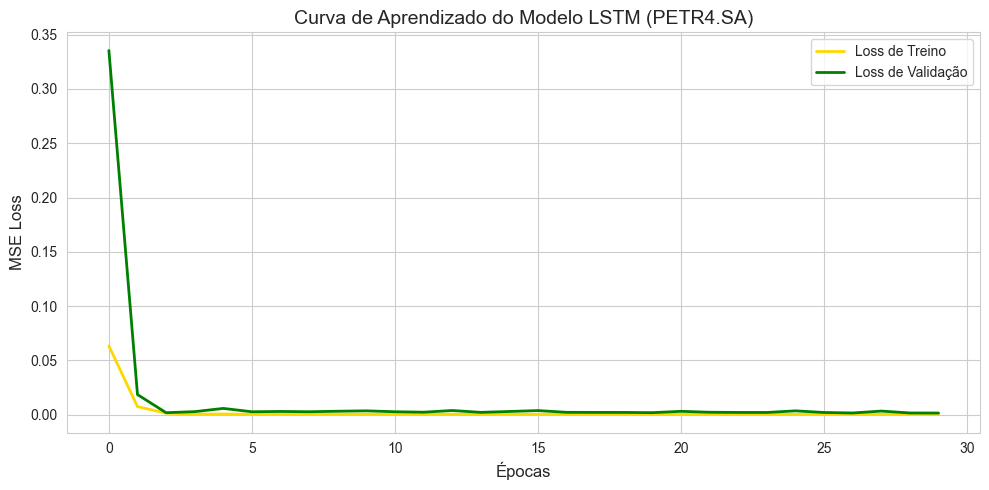

In [16]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))

plt.plot(history['train_loss'], label='Loss de Treino', color='gold', linewidth=2)
plt.plot(history['val_loss'], label='Loss de Validação', color='green', linewidth=2)

plt.title('Curva de Aprendizado do Modelo LSTM (PETR4.SA)', fontsize=14)
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

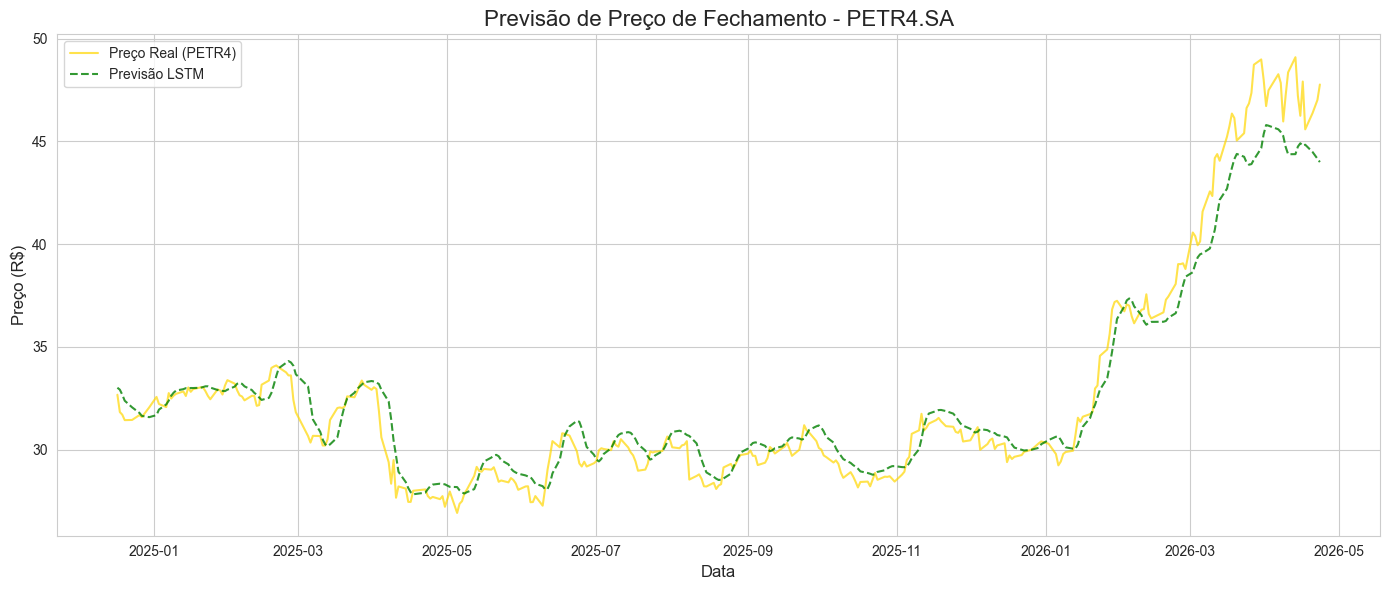

In [17]:
# Célula para plotar Previsões vs Reais
modelo.eval()
with torch.no_grad():
    previsoes_scaled = modelo(X_test).numpy()

# Invertendo o escalonamento para obter os preços reais da ação
previsoes_reais = scaler.inverse_transform(previsoes_scaled)
y_test_real = scaler.inverse_transform(y_test.numpy())

# Extraindo as datas correspondentes ao conjunto de teste
# Como usamos uma janela de 30 dias, os primeiros 30 dias do teste não têm previsão
datas_teste = df.index[split + window_size:]

plt.figure(figsize=(14, 6))
plt.plot(datas_teste, y_test_real, label='Preço Real (PETR4)', color='gold', alpha=0.7)
plt.plot(datas_teste, previsoes_reais, label='Previsão LSTM', color='green', alpha=0.8, linestyle='--')

plt.title('Previsão de Preço de Fechamento - PETR4.SA', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço (R$)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# Certifique-se de que os imports necessários foram feitos no início do notebook
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math
import numpy as np

# Calculando as métricas com as variáveis reais já desescalonadas do seu script
mae = mean_absolute_error(y_test_real, previsoes_reais)
rmse = math.sqrt(mean_squared_error(y_test_real, previsoes_reais))

# MAPE (Mean Absolute Percentage Error) - Erro Percentual Absoluto Médio
# Fórmula: MAPE = (1/n) * Σ(|y_real - y_pred| / |y_real|) * 100
mape = np.mean(np.abs((y_test_real - previsoes_reais) / y_test_real)) * 100

print(f"=== Resultados da Avaliação ===")
print(f"MAE (Erro Médio Absoluto): R$ {mae:.4f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): R$ {rmse:.4f}")
print(f"MAPE (Erro Percentual Absoluto Médio): {mape:.2f}%\n")

print(f"Interpretação:")
print(f"- O modelo erra, em média, R$ {mae:.4f} no preço de fechamento da ação (MAE).")
print(f"- Em termos percentuais, o erro médio das previsões é de {mape:.2f}% em relação ao preço real (MAPE).")
print(f"- O RMSE penaliza erros maiores de forma mais dura, resultando em R$ {rmse:.4f}.")

=== Resultados da Avaliação ===
MAE (Erro Médio Absoluto): R$ 0.8157
RMSE (Raiz do Erro Quadrático Médio): R$ 1.1569
MAPE (Erro Percentual Absoluto Médio): 2.37%

Interpretação:
- O modelo erra, em média, R$ 0.8157 no preço de fechamento da ação (MAE).
- Em termos percentuais, o erro médio das previsões é de 2.37% em relação ao preço real (MAPE).
- O RMSE penaliza erros maiores de forma mais dura, resultando em R$ 1.1569.


C:\Users\igor_\AppData\Local\Temp\ipykernel_15004\3723946550.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  df_anual = df['Close'].resample('Y').mean()
C:\Users\igor_\AppData\Local\Temp\ipykernel_15004\3723946550.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_mensal = df['Close'].resample('M').mean()


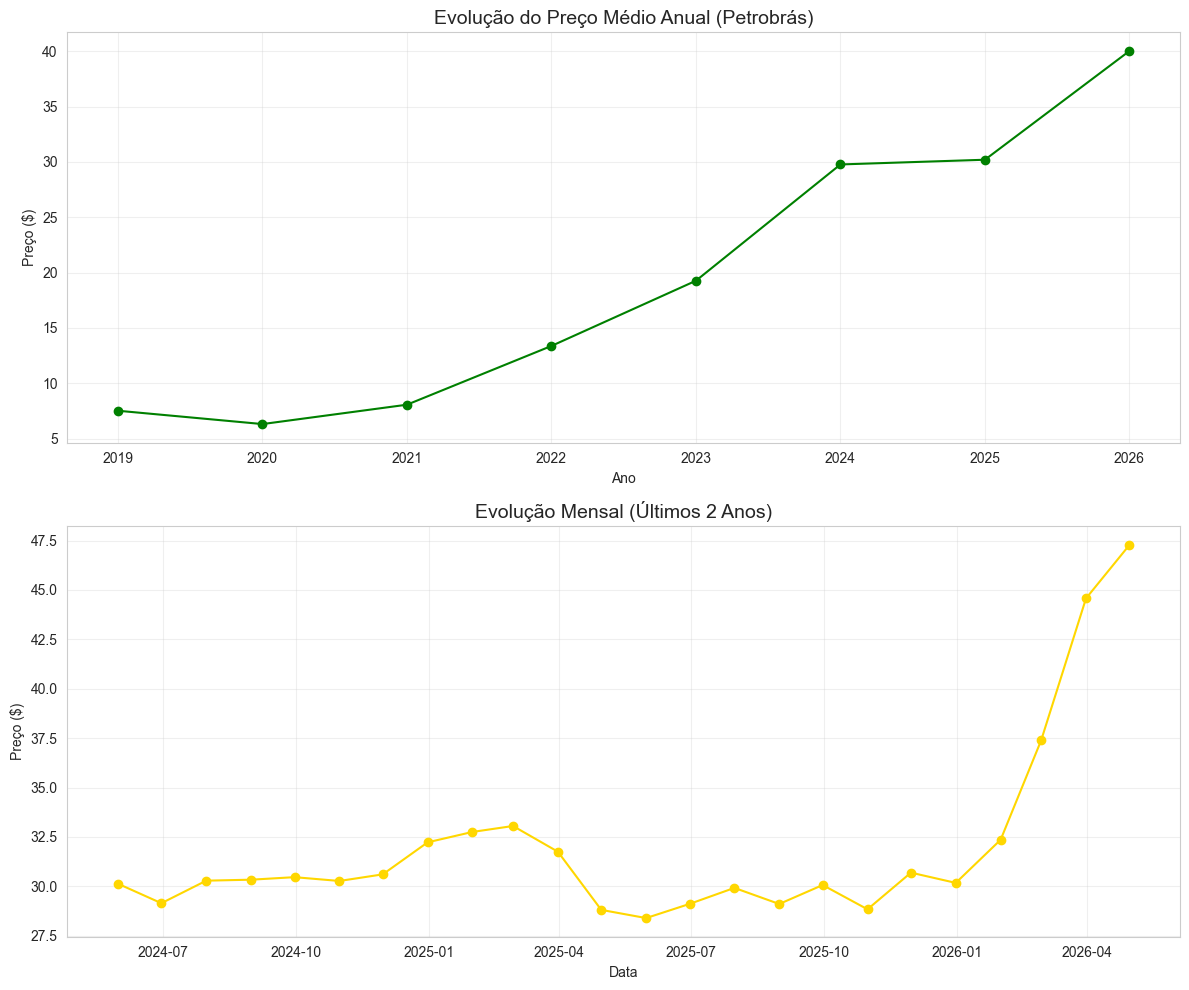

In [19]:
df_anual = df['Close'].resample('Y').mean()
df_mensal = df['Close'].resample('M').mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Gráfico Anual (Cor Verde)
ax1.plot(df_anual.index.year, df_anual.values, marker='o', linestyle='-', color='green')
ax1.set_title('Evolução do Preço Médio Anual (Petrobrás)', fontsize=14)
ax1.set_xlabel('Ano')
ax1.set_ylabel('Preço ($)')
ax1.grid(True, alpha=0.3)

# Gráfico Mensal (Cor Amarela - usando 'gold' para melhor visibilidade)
dados_recentes = df_mensal.iloc[-24:] 
ax2.plot(dados_recentes.index, dados_recentes.values, marker='o', color='gold')
ax2.set_title('Evolução Mensal (Últimos 2 Anos)', fontsize=14)
ax2.set_xlabel('Data')
ax2.set_ylabel('Preço ($)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()